# Đồ án Trực quan hóa Dữ liệu: Climate Lab
## Quy trình Làm sạch Dữ liệu & Khám phá EDA — Nhiệt độ Toàn cầu và Quốc gia
**Thành viên phụ trách:** Huỳnh Cao Trung Đức (Nhóm 18)

Notebook này thực hiện trọn vẹn luồng dữ liệu nhiệt độ:
1. **Làm sạch chuỗi nhiệt độ toàn cầu** từ NASA GISTEMP v4 (1880 – 2025).
2. **Làm sạch & chuẩn hóa chuỗi nhiệt độ quốc gia** từ FAOSTAT (1961 – 2025) bằng chuẩn **UN M49 numeric -> ISO3**, tách bạch chính xác Trung Quốc (`CHN`) khỏi vùng tổng hợp và tách riêng các đặc khu (`HKG`, `MAC`, `TWN`).
3. **Báo cáo kiểm định chất lượng dữ liệu** (Data Quality Audit): Data dictionary, kiểm tra số dòng trước/sau, missing, outlier, các mã không ghép và xuất file `bao_cao_chat_luong.json`.
4. **Khám phá dữ liệu (EDA)**: Notebook xuất 5 biểu đồ tĩnh. File `tao_bieu_do_plotly.py` tạo 6 biểu đồ tương tác: xu hướng theo năm, trung bình thập kỷ, bản đồ quốc gia, heatmap châu lục, boxplot và chênh nhiệt độ theo tháng. Dashboard áp dụng bộ lọc thập kỷ, châu lục và quốc gia. Bảng năm khí tượng giữ giá trị nguồn; bảng `nhiet_do_quoc_gia_nam_lich.csv` tính từ đủ 12 tháng để ghép đúng năm lịch với CO₂. Phần hồi quy tuyến tính được trình bày riêng tại `mo_hinh_du_doan/nguyen_khang`.

### Bước 1: Khai báo thư viện và cấu hình thư mục làm việc

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / 'app.py').is_file() and (p / 'data').is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from phan_tich_nhiet_do.duc.lam_sach_du_lieu import (  # noqa: E402
    clean_nasa, clean_faostat, clean_monthly, clean_calendar_year,
    export_quality_report, NASA_RAW, FAO_RAW, M49_REF, OUT,
)
from bang_dieu_khien.nguyen_khang.thap_ky import country_decade_means, decade_labels  # noqa: E402

FIGURES_DIR = ROOT / 'phan_tich_nhiet_do/duc/bieu_do/tinh'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
OUT.mkdir(parents=True, exist_ok=True)
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False


### Bước 2: Làm sạch dữ liệu nhiệt độ toàn cầu NASA GISTEMP v4 (1880 – 2025)
- Đọc file thô `nasa_nhiet_do_toan_cau_1880_2026.csv`.
- Trích xuất cột `Year` và cột `J-D` (độ lệch nhiệt độ trung bình năm toàn cầu so với thời kỳ cơ sở 1951–1980).
- Loại bỏ năm 2026 do chưa đủ 12 tháng.
- Bổ sung cột thập kỷ `decade` và xuất ra `data/du_lieu_da_xu_ly/duc/nhiet_do_toan_cau.csv`.

In [2]:
df_nasa_final, nasa_stats = clean_nasa()
display(df_nasa_final.head(10))


,year,decade,temperature_anomaly
0,1880,1880,-0.18
1,1881,1880,-0.09
2,1882,1880,-0.12
3,1883,1880,-0.18
4,1884,1880,-0.29
5,1885,1880,-0.34
6,1886,1880,-0.32
7,1887,1880,-0.37
8,1888,1880,-0.18
9,1889,1880,-0.11


### Bước 3: Làm sạch & Chuẩn hóa nhiệt độ quốc gia FAOSTAT (1961 – 2025) bằng chuẩn UN M49 $\rightarrow$ ISO3

> **Quy tắc làm sạch bắt buộc:**
> 1. **Dùng cột `Area Code (M49)`**: Thay vì so khớp chuỗi tên `Area` (dễ lỗi), sử dụng trực tiếp mã số UN M49 numeric để đối chiếu sang ISO-3166-1 alpha-3.
> 2. **Khắc phục lỗi trường hợp Trung Quốc**:
>    - Mã M49 `'156'` (`China, mainland`) $\rightarrow$ gán mã ISO3 chuẩn **`CHN`**, tên chuẩn hóa **`China`**.
>    - Các vùng hành chính đặc quyền và lãnh thổ: `'344'` $\rightarrow$ **`HKG`**, `'446'` $\rightarrow$ **`MAC`**, `'158'` $\rightarrow$ **`TWN`**.
>    - Mã M49 `'159'` (`China` tổng hợp trong FAO) là mã nhóm của FAO $\rightarrow$ tách riêng vào danh sách **vùng tổng hợp (aggregates)** cùng với `World ('001')`, `Asia ('142')`, `Europe ('150')`... để tránh cộng trùng số liệu.
> 3. **Gắn Châu lục**: Dùng danh mục chuẩn của OWID để gán châu lục đồng bộ cho toàn bộ dự án.

**Quy ước thời gian:** dòng `Meteorological year` gồm tháng 12 năm trước đến tháng 11. Giữ chuỗi này phục vụ EDA. Bảng năm lịch riêng lấy trung bình tháng 1–12 và giữ null nếu thiếu tháng. Không tự nội suy, không thay null bằng 0.


In [3]:
df_fao_final, fao_stats = clean_faostat()
df_monthly = clean_monthly()
df_calendar, calendar_stats = clean_calendar_year(df_fao_final, df_monthly)
display(df_fao_final.head(10))
display(df_fao_final[df_fao_final.iso_alpha.isin(['CHN', 'HKG', 'MAC', 'TWN'])]
        [['country', 'iso_alpha', 'continent']].drop_duplicates())
display(pd.DataFrame([calendar_stats]))


,country,iso_alpha,continent,year,decade,temperature_anomaly,source_flag
0,Aruba,ABW,North America,1961,1960,-0.260,E
1,Aruba,ABW,North America,1962,1960,-0.022,E
2,Aruba,ABW,North America,1963,1960,-0.124,E
3,Aruba,ABW,North America,1964,1960,0.045,E
4,Aruba,ABW,North America,1965,1960,-0.299,E
5,Aruba,ABW,North America,1966,1960,-0.004,E
6,Aruba,ABW,North America,1967,1960,-0.377,E
7,Aruba,ABW,North America,1968,1960,-0.172,E
8,Aruba,ABW,North America,1969,1960,0.444,E
9,Aruba,ABW,North America,1970,1970,0.223,E


,country,iso_alpha,continent
2307,China,CHN,Asia
5434,Hong Kong,HKG,Asia
7645,Macao,MAC,Asia
13025,Taiwan,TWN,Asia


,rows_output,year_min,year_max,complete_years,incomplete_years,year_basis
0,14263,1961,2025,13459,804,January–December; required 12 valid monthly va...


### Bước 4: Báo cáo Kiểm tra Chất lượng Dữ liệu (Data Quality Audit) & Data Dictionary
Báo cáo này tổng hợp đầy đủ theo chuẩn khoa học:
1. **Data Dictionary**: Ý nghĩa, kiểu dữ liệu, phạm vi và mốc quy chiếu của từng trường.
2. **Số dòng trước và sau làm sạch** của cả NASA và FAOSTAT.
3. **Tỷ lệ giá trị thiếu (Missing values)** trên từng cột.
4. **Danh sách các vùng tổng hợp (Aggregates)** được tách riêng để không tính trùng.
5. **Phân tích phân phối và Outliers** (IQR: bóc tách rõ ràng ngoại lai nóng và ngoại lai lạnh, kiểm tra cờ dữ liệu).

In [4]:
export_quality_report(nasa_stats, fao_stats, calendar_stats)
display(pd.DataFrame({'NASA': nasa_stats['missing_rate'],
                      'FAOSTAT': fao_stats['missing_rate']}))
print('Đã lưu báo cáo chất lượng và bảng năm lịch dùng khi ghép với CO₂.')


,NASA,FAOSTAT
year,0.0,0.0000
decade,0.0,0.0000
temperature_anomaly,0.0,0.0348
country,NaN,0.0000
iso_alpha,NaN,0.0000
continent,NaN,0.0000
source_flag,NaN,0.0000


Đã lưu báo cáo chất lượng và bảng năm lịch dùng khi ghép với CO₂.


In [5]:
raw_nasa = pd.read_csv(NASA_RAW, header=1, na_values='***').set_index('Year')
np.testing.assert_allclose(df_nasa_final.temperature_anomaly,
                           raw_nasa.loc[df_nasa_final.year, 'J-D'], rtol=0, atol=0)
assert not df_nasa_final.year.duplicated().any()
assert not df_fao_final.duplicated(['iso_alpha', 'year']).any()
assert not df_monthly.duplicated(['iso_alpha', 'year', 'month']).any()
assert df_fao_final.continent.notna().all()

raw_fao = pd.read_csv(FAO_RAW, low_memory=False)
mapping = pd.read_csv(M49_REF, dtype=str).set_index('m49').iso_alpha
raw_annual = raw_fao[raw_fao.Element.eq('Temperature change')
                     & raw_fao.Months.eq('Meteorological year')].copy()
raw_annual['iso_alpha'] = raw_annual['Area Code (M49)'].str.replace("'", '', regex=False).str.zfill(3).map(mapping)
raw_annual = raw_annual.dropna(subset=['iso_alpha']).set_index(['iso_alpha', 'Year'])
indexed = df_fao_final.set_index(['iso_alpha', 'year'])
np.testing.assert_allclose(indexed.temperature_anomaly, raw_annual.loc[indexed.index, 'Value'],
                           rtol=0, atol=0, equal_nan=True)
assert indexed.source_flag.equals(raw_annual.loc[indexed.index, 'Flag'].rename('source_flag'))

monthly = df_monthly[df_monthly.iso_alpha.ne('WLD')]
expected = monthly.groupby(['iso_alpha', 'year']).temperature_anomaly.agg(['mean', 'count'])
calendar = df_calendar.set_index(['iso_alpha', 'year'])
np.testing.assert_allclose(calendar.temperature_anomaly, expected['mean'].where(expected['count'].eq(12)),
                           rtol=1e-12, atol=1e-12, equal_nan=True)
assert calendar.temperature_anomaly.notna().equals(calendar.months_available.eq(12))
display(pd.DataFrame([
    {'CSV': 'nhiet_do_toan_cau', 'Số dòng': len(df_nasa_final), 'Từ năm': df_nasa_final.year.min(),
     'Đến năm': df_nasa_final.year.max(), 'Thiếu nhiệt độ': df_nasa_final.temperature_anomaly.isna().sum()},
    {'CSV': 'nhiet_do_quoc_gia (năm khí tượng)', 'Số dòng': len(df_fao_final), 'Từ năm': df_fao_final.year.min(),
     'Đến năm': df_fao_final.year.max(), 'Thiếu nhiệt độ': df_fao_final.temperature_anomaly.isna().sum()},
    {'CSV': 'nhiet_do_quoc_gia_nam_lich', 'Số dòng': len(df_calendar), 'Từ năm': df_calendar.year.min(),
     'Đến năm': df_calendar.year.max(), 'Thiếu nhiệt độ': df_calendar.temperature_anomaly.isna().sum()},
]))
print('PASS: nhiệt độ và cờ nguồn khớp; không trùng khóa; năm lịch chỉ tính khi đủ 12 tháng.')

,CSV,Số dòng,Từ năm,Đến năm,Thiếu nhiệt độ
0,nhiet_do_toan_cau,146,1880,2025,0
1,nhiet_do_quoc_gia (năm khí tượng),14263,1961,2025,496
2,nhiet_do_quoc_gia_nam_lich,14263,1961,2025,804


PASS: nhiệt độ và cờ nguồn khớp; không trùng khóa; năm lịch chỉ tính khi đủ 12 tháng.


### Bước 5: Trực quan hóa Dữ liệu Khám phá (EDA)
#### 1. Line Chart (Xu hướng nhiệt độ toàn cầu) & 2. Bar Chart (Nhiệt độ theo thập kỷ)

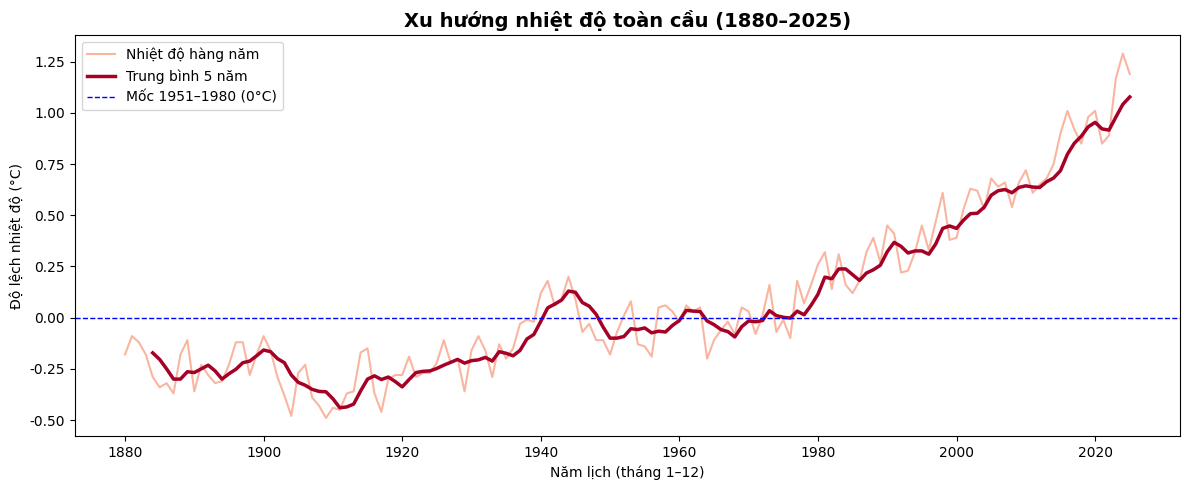

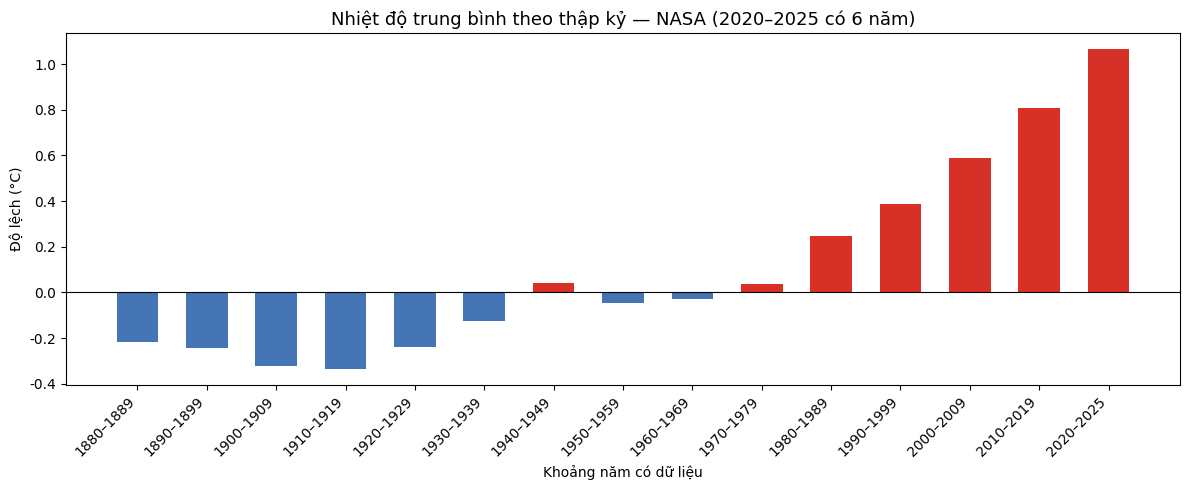

In [6]:
trend = df_nasa_final.assign(rolling_5=df_nasa_final.temperature_anomaly.rolling(5).mean())
plt.figure(figsize=(12, 5))
plt.plot(trend.year, trend.temperature_anomaly, color='#f46d43', alpha=0.5, label='Nhiệt độ hàng năm')
plt.plot(trend.year, trend.rolling_5, color='#a50026', linewidth=2.5, label='Trung bình 5 năm')
plt.axhline(0, color='blue', linestyle='--', linewidth=1, label='Mốc 1951–1980 (0°C)')
plt.title('Xu hướng nhiệt độ toàn cầu (1880–2025)', fontsize=14, fontweight='bold')
plt.xlabel('Năm lịch (tháng 1–12)')
plt.ylabel('Độ lệch nhiệt độ (°C)')
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_xu_huong_nhiet_do_toan_cau.png', dpi=300)
plt.show()

periods = decade_labels(df_nasa_final)
df_dec = df_nasa_final.groupby('decade').temperature_anomaly.agg(['mean', 'count']).reset_index()
df_dec['period'] = df_dec.decade.map(periods)
colors = ['#4575b4' if v < 0 else '#d73027' for v in df_dec['mean']]
plt.figure(figsize=(12, 5))
plt.bar(df_dec.period, df_dec['mean'], color=colors, width=0.6)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Nhiệt độ trung bình theo thập kỷ — NASA (2020–2025 có 6 năm)', fontsize=13)
plt.xlabel('Khoảng năm có dữ liệu')
plt.ylabel('Độ lệch (°C)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_nhiet_do_theo_thap_ky.png', dpi=300)
plt.show()


#### 3. Heatmap (Châu lục x Thập kỷ) & 4. Boxplot (Phân bố nhiệt độ quốc gia)
> **Lưu ý chuẩn thị giác:** Thang màu Heatmap được đặt **tâm tại đúng 0.00°C** (`center=0`), giúp phân định rõ ràng giữa các thập kỷ mang nhiệt độ âm (xanh) và nhiệt độ dương (đỏ).

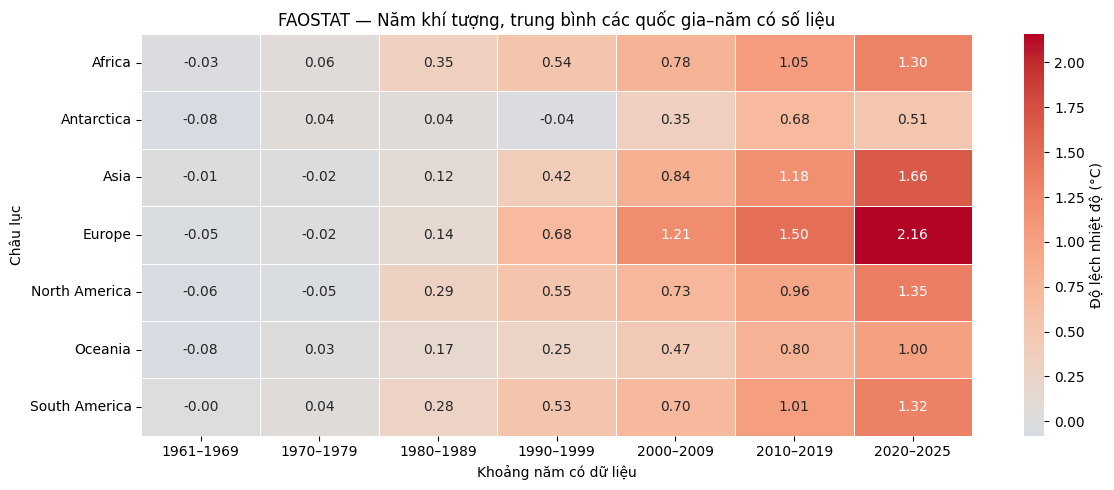

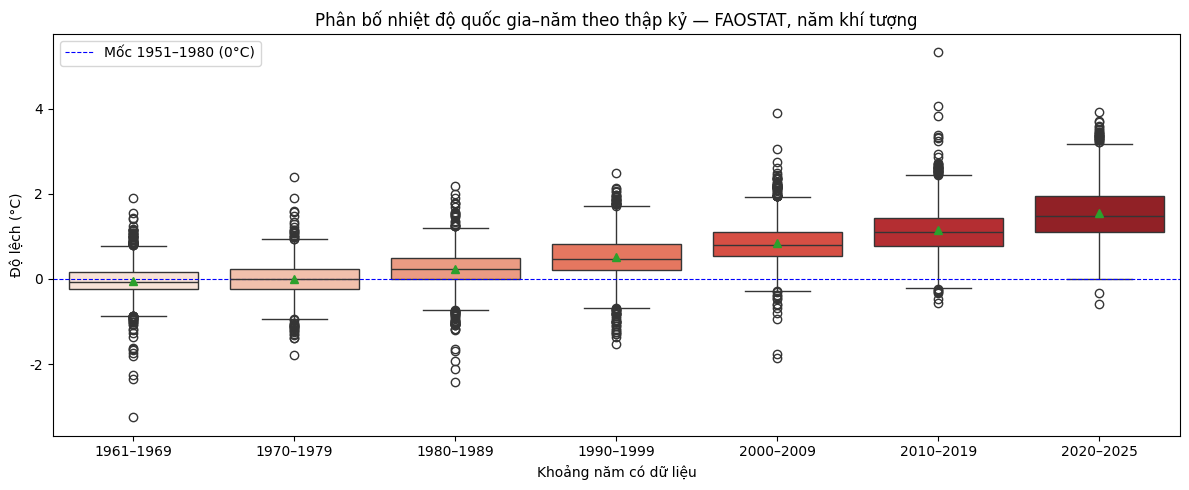

In [7]:
periods = decade_labels(df_fao_final)
pivot_cont = df_fao_final.pivot_table(index='continent', columns='decade',
                                     values='temperature_anomaly', aggfunc='mean')
pivot_cont.columns = [periods[c] for c in pivot_cont.columns]
plt.figure(figsize=(12, 5))
sns.heatmap(pivot_cont, cmap='coolwarm', center=0, annot=True, fmt='.2f', linewidths=0.5,
            cbar_kws={'label': 'Độ lệch nhiệt độ (°C)'})
plt.title('FAOSTAT — Năm khí tượng, trung bình các quốc gia–năm có số liệu', fontsize=12)
plt.xlabel('Khoảng năm có dữ liệu')
plt.ylabel('Châu lục')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_heatmap_chau_luc_thap_ky.png', dpi=300)
plt.show()

box_data = df_fao_final.assign(period=df_fao_final.decade.map(periods))
plt.figure(figsize=(12, 5))
sns.boxplot(data=box_data, x='period', y='temperature_anomaly', hue='period',
            palette='Reds', showmeans=True, legend=False)
plt.axhline(0, color='blue', linestyle='--', linewidth=0.8, label='Mốc 1951–1980 (0°C)')
plt.title('Phân bố nhiệt độ quốc gia–năm theo thập kỷ — FAOSTAT, năm khí tượng', fontsize=12)
plt.xlabel('Khoảng năm có dữ liệu')
plt.ylabel('Độ lệch (°C)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_phan_bo_nhiet_do_quoc_gia.png', dpi=300)
plt.show()


#### 5. Bản đồ nhiệt độ trung bình theo thập kỷ mới nhất
Bản đồ dùng trung bình các năm có số liệu của từng quốc gia trong **2020–2025**;
giai đoạn này có 6 năm, không xem là thập kỷ hoàn chỉnh. Tooltip ghi số năm thực tế.
FAOSTAT là năm khí tượng (tháng 12 năm trước đến tháng 11).
Thang màu cố định −6 đến +6°C, mốc 1951–1980; không thay thiếu dữ liệu bằng 0.


In [8]:
map_data = country_decade_means(df_fao_final, 'temperature_anomaly')
latest = map_data[map_data.decade.eq(map_data.decade.max())]
period = latest.period.iloc[0]
fig_static = px.choropleth(
    latest, locations='iso_alpha', color='temperature_anomaly', hover_name='country',
    hover_data=['period', 'years'], color_continuous_scale='RdBu_r',
    color_continuous_midpoint=0, range_color=[-6, 6],
    title=f'Nhiệt độ trung bình {period}<br>FAOSTAT · năm khí tượng · mốc 1951–1980',
    labels={'temperature_anomaly': 'Độ lệch (°C)', 'years': 'Số năm có dữ liệu'},
    template='plotly_white',
)
fig_static.update_layout(width=900, height=520, title={'x': 0.5, 'font': {'size': 18}})
fig_static.write_image(FIGURES_DIR / '03_ban_do_nhiet_do.png', scale=2)
